# Control de Velocidad de Dron — Perceptrón
### Módulo 3 

---
## El problema

Queremos controlar cuánto aumenta la velocidad de un dron según sus condiciones de vuelo.

| Altura Elevada (X1) | Aceleración Alta (X2) | Aumento de Velocidad |
|:-------------------:|:---------------------:|:--------------------:|
| 0 | 0 | **350** |
| 0 | 1 | **200** |
| 1 | 0 | **200** |
| 1 | 1 | **50**  |

## ¿Qué función de activación usar y por qué?

| Función | Rango | ¿Funciona aquí? |
|---------|-------|----------------|
| **Escalón** | {0, 1} | ❌ La salida debe ser 350, 200, 50 — no cabe |
| **Lineal** | (-∞, +∞) | ✅ La salida es exactamente h sin transformar |
| **ReLU** | [0, +∞) | ⚠️ Solo funciona si h nunca es negativo — puede fallar durante el aprendizaje |
| **Sigmoide** | (0, 1) | ❌ Rango demasiado pequeño |

**Conclusión:** Lineal es la correcta. Probaremos ReLU al final para ver qué diferencia hace.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y machote
# ═══════════════════════════════════════════════════════════════
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

# Ruta relativa al machote
RUTA = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'Machote'))
if RUTA not in sys.path:
    sys.path.append(RUTA)

# Si la ruta falla, descomenta la de tu sistema:
# sys.path.append(r"D:/Proyectos/Diplomado-RNA/Machote")  # Windows
# sys.path.append("/home/usr/Diplomado-RNA/Machote")       # Linux

print("Imports listos ✅")

Imports listos ✅


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Funciones de activación
# ═══════════════════════════════════════════════════════════════

def to_scalar(val):
    """Convierte numpy array de 1 elemento a float (compatible numpy 2.0+)"""
    if hasattr(val, 'flat'): #hasattr verifica si val tiene el atributo 'flat' (numpy array), si es así lo convierte a float, sino lo convierte directamente
        return float(val.flat[0])
    return float(val)

def lineal(h):
    """
    Función lineal: f(h) = h. No transforma nada.
    USAR cuando la salida es un número continuo sin restricción de rango.
    La salida ES la suma ponderada.
    Ejemplo: 350, 200, 50 → cualquier número real.
    """
    return to_scalar(h)

def relu(h):
    """
    ReLU: f(h) = max(0, h). Corta los negativos a 0.
    USAR cuando la salida debe ser positiva.
    PROBLEMA para aprendizaje: si h es negativo durante el entrenamiento,
    la salida es 0 y el error se dispara → pesos oscilan más.
    """
    return max(0.0, to_scalar(h))

def escalon_unitario(h):
    """Escalón: 1 si h >= 0, sino 0. Solo para clasificación binaria."""
    return 1 if to_scalar(h) >= 0 else 0

print("Funciones de activación definidas ✅")

Funciones de activación definidas ✅


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3 — Datos del problema
# ═══════════════════════════════════════════════════════════════

# Entradas: [Altura Elevada, Aceleración Alta]
inputs = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]])

# Salidas esperadas: aumento de velocidad del dron
# No son 0 o 1 → necesitamos función lineal (no escalón)
targets = np.array([350, 200, 200, 50])

print("Datos del problema:")
tabla = []
for i in range(len(inputs)):
    tabla.append([inputs[i][0], inputs[i][1], targets[i]])
print(tabulate(tabla,
               headers=['Altura Elevada', 'Acel. Alta', 'Velocidad'],
               tablefmt='grid'))

Datos del problema:
+------------------+--------------+-------------+
|   Altura Elevada |   Acel. Alta |   Velocidad |
+==================+==============+=============+
|                0 |            0 |         350 |
+------------------+--------------+-------------+
|                0 |            1 |         200 |
+------------------+--------------+-------------+
|                1 |            0 |         200 |
+------------------+--------------+-------------+
|                1 |            1 |          50 |
+------------------+--------------+-------------+


---
# PARTE 1 — Versión Manual (fuerza bruta)

## ¿Cómo calcular los pesos a mano?

Con función lineal, f(h) = h, entonces:
```
h = X1·W1 + X2·W2 + b

Fila (0,0): 0·W1 + 0·W2 + b = b = 350       → b = 350
Fila (0,1): 0·W1 + 1·W2 + 350 = 200          → W2 = 200 - 350 = -150
Fila (1,0): 1·W1 + 0·W2 + 350 = 200          → W1 = 200 - 350 = -150
Fila (1,1): 1·(-150) + 1·(-150) + 350 = 50   ← verificación ✅
```

Cada condición presente (altura alta o aceleración alta) **reduce** la velocidad en 150.
Cuando no hay ninguna condición, la velocidad sube al máximo: 350.

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Versión manual con pesos calculados a mano
# ═══════════════════════════════════════════════════════════════

# Pesos calculados analíticamente (fuerza bruta)
weights_manual = np.array([-150.0, -150.0])
bias_manual    = 350.0

outputs_manual = []
for i in range(len(inputs)):
    h = np.dot(inputs[i], weights_manual) + bias_manual
    y = lineal(h)   # ← LINEAL porque la salida son números continuos
    outputs_manual.append([h, y])

# Mostrar resultados en tabla
print("═" * 65)
print("  VERSIÓN MANUAL — W1=-150, W2=-150, b=350 | f=lineal")
print("═" * 65)

filas = []
correctos = 0
for i in range(len(outputs_manual)):
    x1  = int(inputs[i][0])
    x2  = int(inputs[i][1])
    h   = to_scalar(outputs_manual[i][0])
    fh  = to_scalar(outputs_manual[i][1])
    tgt = float(targets[i])
    ok  = '✅' if abs(fh - tgt) < 1e-6 else '❌'
    if ok == '✅': correctos += 1
    filas.append([x1, x2, h, fh, tgt, ok])

print(tabulate(filas,
               headers=['Altura','Acel','h','Salida','Target','OK'],
               tablefmt='grid',
               floatfmt='.1f'))
print(f"  Resultado: {correctos}/4 correctos {'✅' if correctos==4 else '❌'}")
print()
print("  Interpretación:")
print("    b=350  → velocidad base sin ninguna restricción")
print("    W1=-150 → altura elevada REDUCE la velocidad en 150")
print("    W2=-150 → aceleración alta también REDUCE la velocidad en 150")
print("    Con ambas: 350 - 150 - 150 = 50")

═════════════════════════════════════════════════════════════════
  VERSIÓN MANUAL — W1=-150, W2=-150, b=350 | f=lineal
═════════════════════════════════════════════════════════════════
+----------+--------+-------+----------+----------+------+
|   Altura |   Acel |     h |   Salida |   Target | OK   |
+==========+========+=======+==========+==========+======+
|        0 |      0 | 350.0 |    350.0 |    350.0 | ✅   |
+----------+--------+-------+----------+----------+------+
|        0 |      1 | 200.0 |    200.0 |    200.0 | ✅   |
+----------+--------+-------+----------+----------+------+
|        1 |      0 | 200.0 |    200.0 |    200.0 | ✅   |
+----------+--------+-------+----------+----------+------+
|        1 |      1 |  50.0 |     50.0 |     50.0 | ✅   |
+----------+--------+-------+----------+----------+------+
  Resultado: 4/4 correctos ✅

  Interpretación:
    b=350  → velocidad base sin ninguna restricción
    W1=-150 → altura elevada REDUCE la velocidad en 150
    W2=-150 →

---
# PARTE 2 — Versión con Aprendizaje

Ahora el perceptrón **aprende los pesos solo**, partiendo de valores aleatorios.

La regla de actualización es la misma que en compuertas, pero con función lineal:
```
error    = target - salida_lineal    ← diferencia en velocidad (puede ser 150, -50, etc.)
w_nuevo  = w_viejo + lr * error * x
b_nuevo  = b_viejo + lr * error
```

**¿Por qué el learning_rate importa más aquí que en compuertas?**

En compuertas, el error máximo era 1 (target y salida son 0 o 1).
Aquí el error puede ser 350 (si predice 0 cuando debe dar 350).
Con lr=0.001 y error=350: ajuste = 0.001 × 350 = 0.35 → muy pequeño, necesita muchas épocas.
Con lr=0.01 y error=350: ajuste = 0.01 × 350 = 3.5 → 10 veces más grande, converge más rápido.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Función de entrenamiento para regresión (salida continua)
# ═══════════════════════════════════════════════════════════════

def entrenar_perceptron_regresion(nombre, inputs, targets,
                                   learning_rate=0.01,
                                   epochs=100,
                                   funcion_activacion=lineal,
                                   tolerancia=1.0,
                                   seed=42,
                                   verbose=False):
    """
    Entrena un perceptrón para regresión (salidas continuas).

    Diferencias respecto al perceptrón de clasificación:
      - La función de activación es lineal (o ReLU) en lugar de escalón
      - El error puede ser grande (ej: 350) no solo 0, 1 o -1
      - Usamos tolerancia en vez de 'error == 0' para detectar convergencia
        (convergió cuando el error en TODAS las filas es < tolerancia)

    Parámetros:
        nombre              → nombre del problema
        inputs              → array de entradas
        targets             → array de salidas esperadas (números continuos)
        learning_rate       → tamaño del ajuste por error
        epochs              → número máximo de épocas
        funcion_activacion  → lineal o relu
        tolerancia          → error máximo permitido para considerar correcto
        seed                → semilla para reproducibilidad
        verbose             → si True, imprime detalle de cada época

    Regresa:
        historial → dict con listas de error_mse, w1, w2, bias por época
    """
    np.random.seed(seed)
    # Pesos iniciales pequeños (escala proporcional al rango de targets)
    escala = np.std(targets) * 0.01
    weights = np.random.randn(2) * escala
    bias    = np.array([np.mean(targets)])  # iniciar bias en la media de targets

    nombre_func = funcion_activacion.__name__ # obtener el nombre de la función para imprimirlo
    print(f"\n{'═'*65}")
    print(f"  {nombre} | lr={learning_rate} | épocas={epochs} | f={nombre_func}")
    print(f"{'═'*65}")
    print(f"  Pesos iniciales: W1={weights[0]:.2f}  W2={weights[1]:.2f}  b={bias[0]:.2f}")

    historial = {
        'error_mse': [],   # Error Cuadrático Medio por época
        'error_mae': [],   # Error Absoluto Medio por época (más interpretable)
        'w1':        [],
        'w2':        [],
        'bias':      [],
    }

    epocas_convergencia = None

    for epoch in range(epochs):
        errores_epoca = []

        if verbose and (epoch < 5 or epoch % 10 == 9):
            print(f"\n  ── Época {epoch+1} ──")
            print(f"  {'Altura':>7} {'Acel':>5} {'Target':>8} {'Salida':>8} {'Error':>8}")

        for i in range(len(inputs)):
            x      = inputs[i].astype(float)
            target = float(targets[i])

            # 1. Suma ponderada
            h = np.dot(x, weights) + bias

            # 2. Función de activación (lineal o relu)
            y = funcion_activacion(h)

            # 3. Error (puede ser grande: target=350, y=0 → error=350)
            error = target - y
            errores_epoca.append(abs(error)) #abs devuelve el valor absoluto del error, para contar cuántos errores hubo sin importar si fueron positivos o negativos

            # 4. Actualizar pesos proporcional al error
            weights = weights + learning_rate * error * x
            bias    = bias    + learning_rate * error

            if verbose and (epoch < 5 or epoch % 10 == 9):
                print(f"  {int(x[0]):>7} {int(x[1]):>5} {target:>8.1f} {y:>8.1f} {error:>8.1f}")

        # Calcular métricas de la época
        mse = np.mean([e**2 for e in errores_epoca])
        mae = np.mean(errores_epoca)

        historial['error_mse'].append(mse)
        historial['error_mae'].append(mae)
        historial['w1'].append(float(weights[0]))
        historial['w2'].append(float(weights[1]))
        historial['bias'].append(float(bias[0]))

        if verbose and (epoch < 5 or epoch % 10 == 9):
            print(f"  MAE={mae:.2f}  MSE={mse:.2f}")

        # Convergencia: todos los errores menores a tolerancia
        if all(e < tolerancia for e in errores_epoca) and epocas_convergencia is None:
            epocas_convergencia = epoch + 1
            if not verbose:
                break

    print(f"\n  Pesos finales: W1={weights[0]:.4f}  W2={weights[1]:.4f}  b={float(bias[0]):.4f}")
    print(f"  MAE final:     {historial['error_mae'][-1]:.4f}")
    if epocas_convergencia:
        print(f"  ✅ Convergió en época {epocas_convergencia} (error < {tolerancia})")
    else:
        print(f"  ⚠️  No convergió en {epochs} épocas (MAE={historial['error_mae'][-1]:.2f})")

    # Tabla final con los pesos aprendidos
    print(f"\n  Predicciones finales:")
    filas = []
    for i in range(len(inputs)):
        h   = np.dot(inputs[i].astype(float), weights) + bias
        y   = funcion_activacion(h)
        tgt = float(targets[i])
        ok  = '✅' if abs(y - tgt) < tolerancia else '❌'
        filas.append([int(inputs[i][0]), int(inputs[i][1]),
                      round(float(to_scalar(h)), 2),
                      round(y, 2), tgt, ok])
    print(tabulate(filas,
                   headers=['Altura','Acel','h','Salida','Target','OK'],
                   tablefmt='grid',
                   floatfmt='.2f'))

    return historial


print("Función de entrenamiento definida ✅")

Función de entrenamiento definida ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Función para graficar evolución por épocas
# ═══════════════════════════════════════════════════════════════

def graficar_evolucion_regresion(nombre, historial, color='#D85A30'):
    """
    Grafica la evolución del entrenamiento para problemas de regresión.

    Gráficas:
      1. MAE por época — el error promedio en las unidades del problema
                         (aquí en 'unidades de velocidad')
                         Más interpretable que MSE para el humano.
      2. MSE por época — penaliza más los errores grandes. Baja más rápido
                         cuando el modelo mejora mucho de golpe.
      3. Pesos y bias  — cómo cambian durante el entrenamiento.
                         Cuando se estabilizan, el modelo convergió.
    """
    epocas = list(range(1, len(historial['error_mse']) + 1))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Evolución del aprendizaje — {nombre}',
                 fontsize=14, fontweight='bold')

    # ── Gráfica 1: MAE por época ──────────────────────────────
    # MAE = Error Absoluto Medio en las mismas unidades que el target
    # Aquí el target es velocidad → MAE está en 'unidades de velocidad'
    # Si MAE=50 → el modelo se equivoca en promedio 50 unidades de velocidad
    axes[0].plot(epocas, historial['error_mae'], 'o-',
                 color=color, linewidth=2, markersize=5)
    axes[0].fill_between(epocas, historial['error_mae'], alpha=0.1, color=color)
    axes[0].axhline(y=1.0, color='green', linewidth=1.5, linestyle='--',
                    label='Tolerancia = 1.0')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('MAE (unidades de velocidad)')
    axes[0].set_title('Error Absoluto Medio (MAE)')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # ── Gráfica 2: MSE por época ──────────────────────────────
    # MSE = Mean Squared Error. Penaliza errores grandes más que pequeños.
    # Un error de 100 pesa 100² = 10,000 vs un error de 10 que pesa 10² = 100.
    axes[1].plot(epocas, historial['error_mse'], 's-',
                 color='#3B8BD4', linewidth=2, markersize=5)
    axes[1].fill_between(epocas, historial['error_mse'], alpha=0.1, color='#3B8BD4')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('MSE')
    axes[1].set_title('Error Cuadrático Medio (MSE)')
    axes[1].grid(True, alpha=0.3)

    # ── Gráfica 3: Evolución de pesos y bias ──────────────────
    axes[2].plot(epocas, historial['w1'],   's-',
                 color='#3B8BD4', linewidth=2, markersize=5, label='W1')
    axes[2].plot(epocas, historial['w2'],   'o-',
                 color='#D85A30', linewidth=2, markersize=5, label='W2')
    axes[2].plot(epocas, historial['bias'], 'd-',
                 color='#2ca02c', linewidth=2, markersize=5, label='bias')

    # Líneas de referencia con los pesos óptimos (calculados a mano)
    axes[2].axhline(y=-150, color='#3B8BD4', linewidth=1, linestyle=':',
                    alpha=0.7, label='W1 óptimo (-150)')
    axes[2].axhline(y=-150, color='#D85A30', linewidth=1, linestyle=':',
                    alpha=0.7)
    axes[2].axhline(y=350,  color='#2ca02c', linewidth=1, linestyle=':',
                    alpha=0.7, label='bias óptimo (350)')

    axes[2].set_xlabel('Época')
    axes[2].set_ylabel('Valor del parámetro')
    axes[2].set_title('Evolución de pesos y bias')
    axes[2].legend(fontsize=7)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Función de gráficas definida ✅")

Función de gráficas definida ✅


---
## Experimento 1 — Función LINEAL 

Con función lineal, la salida del perceptrón ES la suma ponderada sin modificar.
El error refleja exactamente con cuánta "velocidad" nos equivocamos.


═════════════════════════════════════════════════════════════════
  Dron — Función Lineal | lr=0.01 | épocas=1000 | f=lineal
═════════════════════════════════════════════════════════════════
  Pesos iniciales: W1=0.53  W2=-0.15  b=200.00

  ── Época 1 ──
   Altura  Acel   Target   Salida    Error
        0     0    350.0    200.0    150.0
        0     1    200.0    201.4     -1.4
        1     0    200.0    202.0     -2.0
        1     1     50.0    201.8   -151.8
  MAE=76.29  MSE=11388.26

  ── Época 2 ──
   Altura  Acel   Target   Salida    Error
        0     0    350.0    199.9    150.1
        0     1    200.0    199.8      0.2
        1     0    200.0    200.4     -0.4
        1     1     50.0    198.8   -148.8
  MAE=74.87  MSE=11160.94

  ── Época 3 ──
   Altura  Acel   Target   Salida    Error
        0     0    350.0    200.0    150.0
        0     1    200.0    198.3      1.7
        1     0    200.0    199.0      1.0
        1     1     50.0    195.8   -145.8
  MAE=74.65  

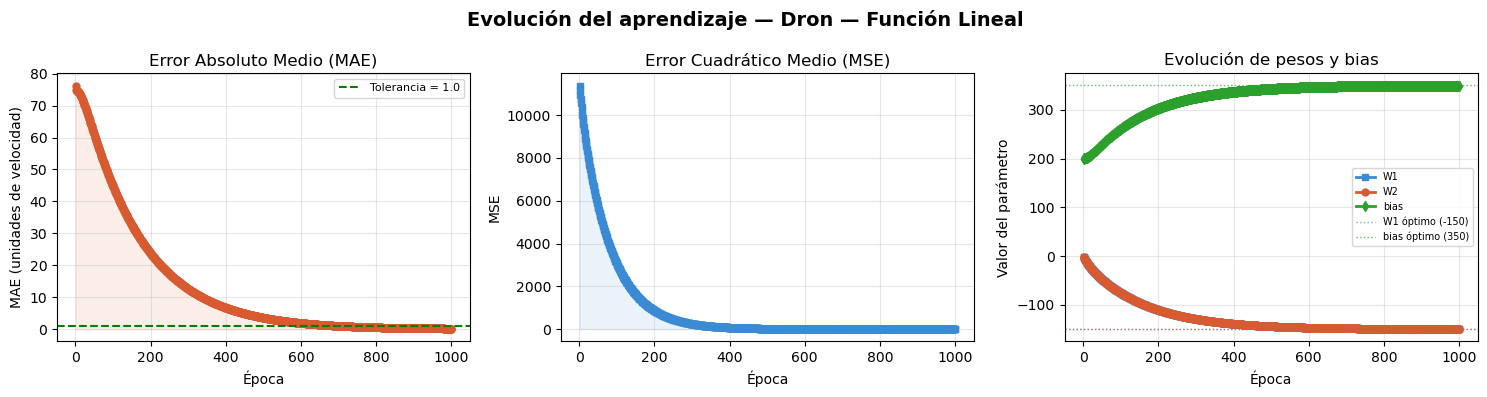

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7 — Entrenamiento con función LINEAL
# ═══════════════════════════════════════════════════════════════
hist_lineal = entrenar_perceptron_regresion(
    nombre='Dron — Función Lineal',
    inputs=inputs,
    targets=targets,
    learning_rate=0.01,   # lr adecuado para errores del orden de 350
    epochs=1_000,          # más épocas para asegurar convergencia
    funcion_activacion=lineal,
    tolerancia=1.0,       # tolerancia: error < 1 unidad de velocidad
    seed=42,
    verbose=True          # True para ver el detalle de las primeras épocas
)

graficar_evolucion_regresion('Dron — Función Lineal', hist_lineal)

---
## Experimento 2 — ¿Qué pasa con ReLU?

ReLU corta los negativos a 0. Durante el aprendizaje, cuando los pesos
son aleatorios, `h` puede ser negativo → ReLU da 0 → error = target - 0 = 350.

Eso hace que los pesos den saltos grandes al principio, lo que puede
hacer que el aprendizaje sea más inestable.

Aun así, como los targets son siempre positivos (350, 200, 50),
ReLU **puede funcionar** — el modelo aprende a mantener h positivo.


═════════════════════════════════════════════════════════════════
  Dron — Función ReLU | lr=0.01 | épocas=1000 | f=relu
═════════════════════════════════════════════════════════════════
  Pesos iniciales: W1=0.53  W2=-0.15  b=200.00

  Pesos finales: W1=-149.1778  W2=-149.1741  b=349.0105
  MAE final:     0.4966
  ✅ Convergió en época 811 (error < 1.0)

  Predicciones finales:
+----------+--------+--------+----------+----------+------+
|   Altura |   Acel |      h |   Salida |   Target | OK   |
+==========+========+========+==========+==========+======+
|        0 |      0 | 349.01 |   349.01 |   350.00 | ✅   |
+----------+--------+--------+----------+----------+------+
|        0 |      1 | 199.84 |   199.84 |   200.00 | ✅   |
+----------+--------+--------+----------+----------+------+
|        1 |      0 | 199.83 |   199.83 |   200.00 | ✅   |
+----------+--------+--------+----------+----------+------+
|        1 |      1 |  50.66 |    50.66 |    50.00 | ✅   |
+----------+--------+-

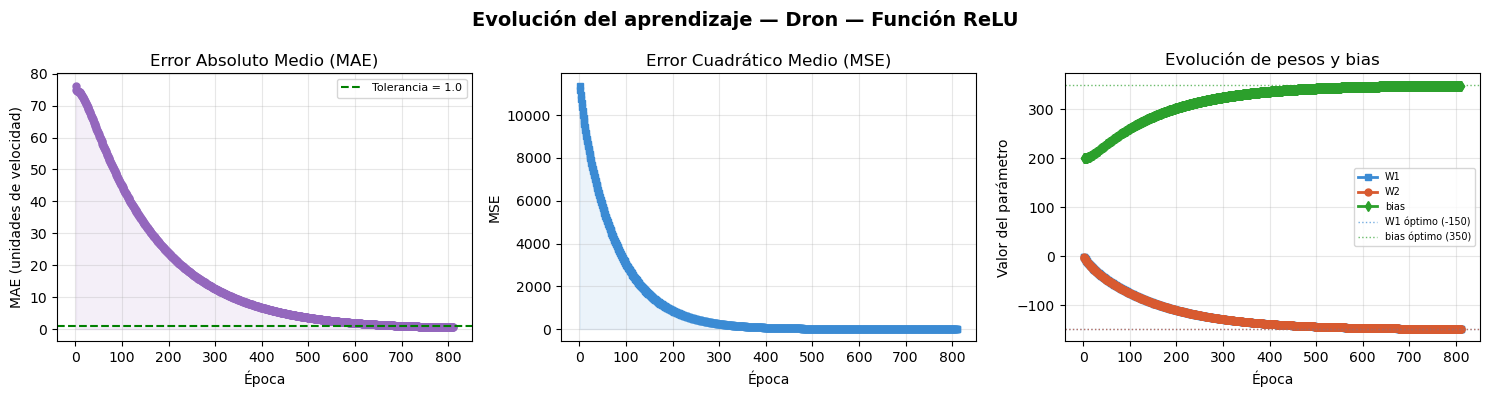

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8 — Entrenamiento con función RELU (comparación)
# ═══════════════════════════════════════════════════════════════
hist_relu = entrenar_perceptron_regresion(
    nombre='Dron — Función ReLU',
    inputs=inputs,
    targets=targets,
    learning_rate=0.01,
    epochs=1_000,
    funcion_activacion=relu,
    tolerancia=1.0,
    seed=42,
    verbose=False  # False para no ver el detalle (puede ser largo)
)

graficar_evolucion_regresion('Dron — Función ReLU', hist_relu, color='#9467bd')

Pesos finales aprendidos:
+----------------+-----------+-----------+----------+
| Parámetro      |    Lineal |      ReLU | Óptimo   |
+================+===========+===========+==========+
| W1 aprendido   | -149.751  | -149.178  | -150.0   |
+----------------+-----------+-----------+----------+
| W2 aprendido   | -149.75   | -149.174  | -150.0   |
+----------------+-----------+-----------+----------+
| bias aprendido |  349.701  |  349.01   | 350.0    |
+----------------+-----------+-----------+----------+
| MAE final      |    0.1501 |    0.4966 | 0.0      |
+----------------+-----------+-----------+----------+
| Épocas usadas  | 1000      |  811      | -        |
+----------------+-----------+-----------+----------+


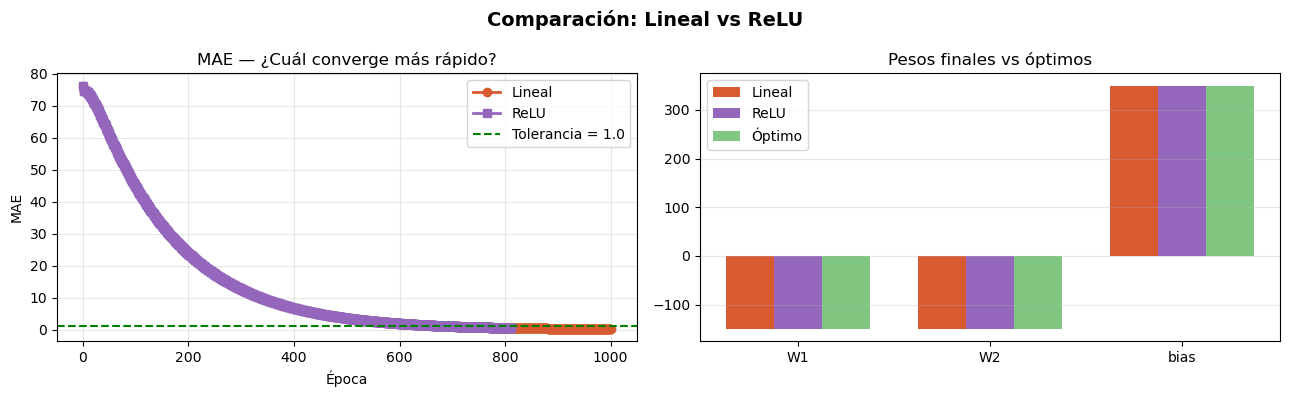

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELDA 9 — Comparación directa Lineal vs ReLU
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Comparación: Lineal vs ReLU', fontsize=14, fontweight='bold')

ep_lin  = list(range(1, len(hist_lineal['error_mae']) + 1))
ep_relu = list(range(1, len(hist_relu['error_mae']) + 1))

# MAE comparison
axes[0].plot(ep_lin,  hist_lineal['error_mae'], 'o-',
             color='#D85A30', linewidth=2, label='Lineal')
axes[0].plot(ep_relu, hist_relu['error_mae'],   's-',
             color='#9467bd', linewidth=2, label='ReLU')
axes[0].axhline(y=1.0, color='green', linewidth=1.5,
                linestyle='--', label='Tolerancia = 1.0')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE — ¿Cuál converge más rápido?')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pesos finales comparison
categorias = ['W1 aprendido', 'W1 óptimo',
               'W2 aprendido', 'W2 óptimo',
               'bias aprendido', 'bias óptimo']
val_lineal = [hist_lineal['w1'][-1],  -150,
              hist_lineal['w2'][-1],  -150,
              hist_lineal['bias'][-1], 350]
val_relu   = [hist_relu['w1'][-1],  -150,
              hist_relu['w2'][-1],  -150,
              hist_relu['bias'][-1], 350]

print("Pesos finales aprendidos:")
tabla_comp = [
    ['W1 aprendido',   f"{hist_lineal['w1'][-1]:.4f}",
                       f"{hist_relu['w1'][-1]:.4f}",   '-150.0'],
    ['W2 aprendido',   f"{hist_lineal['w2'][-1]:.4f}",
                       f"{hist_relu['w2'][-1]:.4f}",   '-150.0'],
    ['bias aprendido', f"{hist_lineal['bias'][-1]:.4f}",
                       f"{hist_relu['bias'][-1]:.4f}",  '350.0'],
    ['MAE final',      f"{hist_lineal['error_mae'][-1]:.4f}",
                       f"{hist_relu['error_mae'][-1]:.4f}", '0.0'],
    ['Épocas usadas',  str(len(ep_lin)), str(len(ep_relu)), '-'],
]
print(tabulate(tabla_comp,
               headers=['Parámetro', 'Lineal', 'ReLU', 'Óptimo'],
               tablefmt='grid'))

# Bias comparison chart
x_pos = [0, 1, 2]
labels = ['W1', 'W2', 'bias']
vals_lin  = [hist_lineal['w1'][-1], hist_lineal['w2'][-1], hist_lineal['bias'][-1]]
vals_relu = [hist_relu['w1'][-1],   hist_relu['w2'][-1],   hist_relu['bias'][-1]]
vals_opt  = [-150, -150, 350]

ancho = 0.25
axes[1].bar([x - ancho for x in x_pos], vals_lin,  ancho, label='Lineal', color='#D85A30')
axes[1].bar(x_pos,                       vals_relu, ancho, label='ReLU',   color='#9467bd')
axes[1].bar([x + ancho for x in x_pos], vals_opt,  ancho, label='Óptimo', color='#2ca02c', alpha=0.6)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels)
axes[1].set_title('Pesos finales vs óptimos')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Experimento 3 — ¿Qué pasa con diferentes learning rates?

Aquí puedes ver por qué lr=0.001 daba error con solo 20 épocas:
los ajustes son tan pequeños que el modelo no alcanza a converger.


═════════════════════════════════════════════════════════════════
  lr=0.001 | lr=0.001 | épocas=1000 | f=lineal
═════════════════════════════════════════════════════════════════
  Pesos iniciales: W1=0.53  W2=-0.15  b=200.00

  Pesos finales: W1=-74.9969  W2=-75.2345  b=261.1165
  MAE final:     44.4578
  ⚠️  No convergió en 1000 épocas (MAE=44.46)

  Predicciones finales:
+----------+--------+--------+----------+----------+------+
|   Altura |   Acel |      h |   Salida |   Target | OK   |
+==========+========+========+==========+==========+======+
|        0 |      0 | 261.12 |   261.12 |   350.00 | ❌   |
+----------+--------+--------+----------+----------+------+
|        0 |      1 | 185.88 |   185.88 |   200.00 | ❌   |
+----------+--------+--------+----------+----------+------+
|        1 |      0 | 186.12 |   186.12 |   200.00 | ❌   |
+----------+--------+--------+----------+----------+------+
|        1 |      1 | 110.89 |   110.89 |    50.00 | ❌   |
+----------+--------+-----

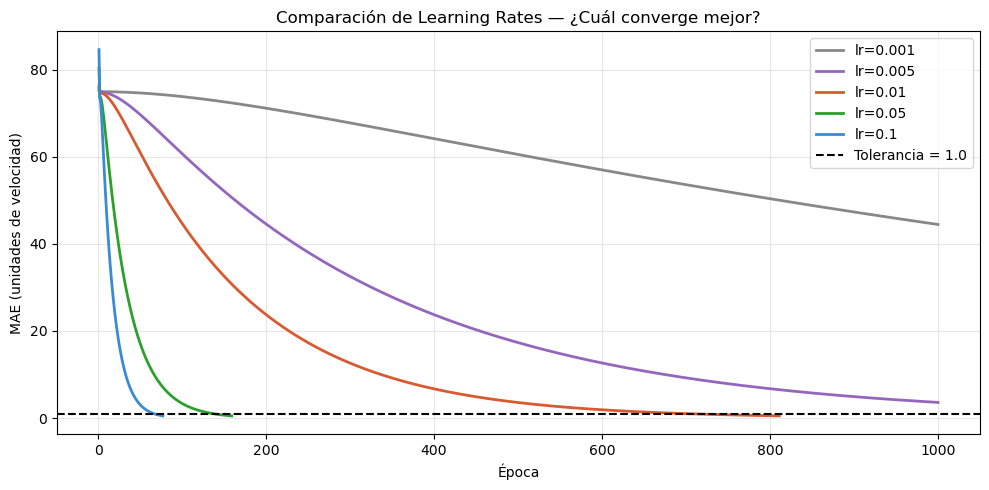


Resumen por learning rate:
+-----------------+-----------------+-------------+-------------+
|   Learning Rate |   Épocas usadas |   MAE final | Convergió   |
+=================+=================+=============+=============+
|           0.001 |            1000 |     44.4578 | ❌          |
+-----------------+-----------------+-------------+-------------+
|           0.005 |            1000 |      3.5821 | ❌          |
+-----------------+-----------------+-------------+-------------+
|           0.01  |             811 |      0.4966 | ✅          |
+-----------------+-----------------+-------------+-------------+
|           0.05  |             159 |      0.4838 | ✅          |
+-----------------+-----------------+-------------+-------------+
|           0.1   |              77 |      0.4827 | ✅          |
+-----------------+-----------------+-------------+-------------+

Observa:
  lr=0.001 → muy lento, necesita muchas más épocas
  lr=0.1   → puede oscilar (ajustes demasiado grandes)
  l

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELDA 10 — Comparar diferentes learning rates
# ═══════════════════════════════════════════════════════════════

learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
historiales_lr = {}

for lr in learning_rates:
    h = entrenar_perceptron_regresion(
        nombre=f'lr={lr}',
        inputs=inputs,
        targets=targets,
        learning_rate=lr,
        epochs=1_000,
        funcion_activacion=lineal,
        tolerancia=1.0,
        seed=42,
        verbose=False
    )
    historiales_lr[lr] = h

# Graficar comparación de MAE para cada lr
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#888', '#9467bd', '#D85A30', '#2ca02c', '#3B8BD4']

for (lr, hist), color in zip(historiales_lr.items(), colores):
    ep = list(range(1, len(hist['error_mae']) + 1))
    ax.plot(ep, hist['error_mae'], linewidth=2, label=f'lr={lr}', color=color)

ax.axhline(y=1.0, color='black', linewidth=1.5,
            linestyle='--', label='Tolerancia = 1.0')
ax.set_xlabel('Época')
ax.set_ylabel('MAE (unidades de velocidad)')
ax.set_title('Comparación de Learning Rates — ¿Cuál converge mejor?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen por learning rate:")
resumen = []
for lr, hist in historiales_lr.items():
    epocas_usadas = len(hist['error_mae'])
    mae_final     = hist['error_mae'][-1]
    convergio     = '✅' if mae_final < 1.0 else '❌'
    resumen.append([lr, epocas_usadas, f"{mae_final:.4f}", convergio])

print(tabulate(resumen,
               headers=['Learning Rate', 'Épocas usadas', 'MAE final', 'Convergió'],
               tablefmt='grid'))

print()
print("Observa:")
print("  lr=0.001 → muy lento, necesita muchas más épocas")
print("  lr=0.1   → puede oscilar (ajustes demasiado grandes)")
print("  lr=0.01  → buen balance entre velocidad y estabilidad")

---
## Resumen final

```
Versión manual (fuerza bruta):
   Nosotros calculamos: W1=-150, W2=-150, b=350
   Lo hicimos despejando h = X1·W1 + X2·W2 + b para cada fila.

Versión con aprendizaje:
   El perceptrón empieza con pesos aleatorios y los ajusta solo.
   Regla: w = w + lr * error * x  donde error = target - salida

¿Por qué función lineal y no escalón ni sigmoide?
   Porque la salida son números continuos (350, 200, 50).
   El escalón solo puede dar 0 o 1 → no alcanza para estos valores.

¿Por qué ReLU puede dar problemas?
   Si h es negativo durante el entrenamiento, ReLU da 0.
   Error = target - 0 = 350 → ajuste gigante → inestabilidad.
   Lineal no tiene este problema.

¿Por qué lr=0.001 daba error con 20 épocas?
   Con error=350 y lr=0.001: ajuste = 0.001 * 350 = 0.35 por paso.
   Con error=350 y lr=0.01:  ajuste = 0.01 * 350 = 3.5 por paso.
   lr=0.001 necesita 10 veces más épocas para llegar al mismo lugar.
```